# Debug — Cross-attention idéntica para todas las palabras

Notebook de diagnóstico para responder: **¿por qué los mapas de cross-attention son prácticamente iguales para distintas palabras?**

Hay cuatro hipótesis ordenadas por probabilidad:

| # | Hipótesis | Síntoma diagnóstico |
|---|-----------|---------------------|
| 1 | `hook_fires ≠ n_tokens` — el hook dispara más veces de lo esperado (beam search, llamadas extra) | `len(captured) >> len(tokens)` |
| 2 | Dimensión `T` mal indexada — se lee siempre la misma posición del eje temporal | `shape[-2] > 1` y se usa índice fijo |
| 3 | Las capturas son numéricamente idénticas — `clone()` no funcionó o hay aliasing | `max_diff ≈ 0` entre capturas |
| 4 | La capa elegida ya no tiene señal espacial — capa 11 produce atención degenerada | mapas mejoran con capa 5–9 |

Cada sección diagnostica una hipótesis y propone un fix si se confirma.

## 0. Configuración

In [1]:
# ── Completar si hace falta ────────────────────────────────────────────────
IMAGE_PATH  = "../data/img_prueba/perro.jpg"   # ← imagen de prueba
MODEL_DIR   = "../models/blip_base"               # ← modelo local
LAYER_RANGE = [5, 7, 8, 9, 11]                    # ← capas a comparar en la Sección 6

## 1. Imports y paths

In [2]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.models.blip_loader import load_model_and_processor
from src.interpretability.cross_attention import eval_and_extract_cross_att

image_path = Path(IMAGE_PATH)
model_dir  = Path(MODEL_DIR)
assert image_path.exists(), f"No encontré la imagen: {image_path.resolve()}"
assert model_dir.exists(),  f"No encontré el modelo: {model_dir.resolve()}"

print(f"ROOT      : {ROOT}")
print(f"Imagen    : {image_path.resolve()}")
print(f"Device    : {'GPU — ' + torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}"
)

ROOT      : /home/felisl/Escritorio/feli/vision/segunda_parte/tp_final/image-captioning
Imagen    : /home/felisl/Escritorio/feli/vision/segunda_parte/tp_final/image-captioning/data/img_prueba/perro.jpg
Device    : CPU


## 2. Cargar modelo

In [3]:
model, processor = load_model_and_processor(model_dir=model_dir)
device = next(model.parameters()).device
model.eval()
print(f"Modelo cargado en: {device}")

Loading weights:   0%|          | 0/471 [00:00<?, ?it/s]

Modelo cargado en: cpu


## 3. Cargar imagen

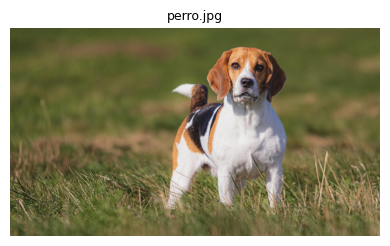

Tamaño PIL         : (1280, 720)
pixel_values shape : torch.Size([1, 3, 384, 384])


In [4]:
from PIL import Image

image  = Image.open(image_path).convert("RGB")
inputs = processor(images=image, return_tensors="pt").to(str(device))

fig, ax = plt.subplots(1, 1, figsize=(4, 4), dpi=100)
ax.imshow(image)
ax.axis("off")
ax.set_title(image_path.name, fontsize=9)
plt.tight_layout()
plt.show()

print(f"Tamaño PIL         : {image.size}")
print(f"pixel_values shape : {inputs['pixel_values'].shape}")

## 4. GenerationConfig — ¿está activo beam search?

Si `num_beams > 1`, el hook dispara **num_beams veces por token** en lugar de una.
Eso hace que `captured[0..k-1]` correspondan todos al mismo token (k = num_beams),
y el mapeo `captured[i] ↔ tokens[i]` queda desfasado.

**Fix:** forzar `num_beams=1` en `generate()`.

In [5]:
gc = model.generation_config
print("GenerationConfig:")
print(f"  num_beams           : {gc.num_beams}")
print(f"  do_sample           : {gc.do_sample}")
print(f"  max_length          : {gc.max_length}")
print(f"  num_return_sequences: {getattr(gc, 'num_return_sequences', 1)}")
print()
if gc.num_beams > 1:
    print(f"⚠️  BEAM SEARCH ACTIVO (num_beams={gc.num_beams}) — el hook dispara {gc.num_beams}× por token.")
    print("   Fix: pasar num_beams=1 a generate() en eval_and_extract_cross_att.")
else:
    print("✓  Beam search desactivado — el hook debería disparar 1× por token.")

GenerationConfig:
  num_beams           : 1
  do_sample           : False
  max_length          : 20
  num_return_sequences: 1

✓  Beam search desactivado — el hook debería disparar 1× por token.


## 5. Hipótesis 1 — ¿cuántas veces dispara el hook?

El hook debería disparar **exactamente `n_tokens` veces** (una por paso de generación).
Si `len(captured) > len(tokens)`, hay capturas extra que desfasan el mapeo.

**Resultado esperado:** `hook_fires == n_tokens` o `hook_fires == n_tokens + 1` (el +1 es el token EOS).

In [6]:
captured_raw = []

def hook_count(module, inp, output):
    if isinstance(output, tuple) and len(output) > 1 and output[1] is not None:
        attn = output[1]
        if attn.shape[-1] == 577:
            captured_raw.append(attn.detach().clone())

LAYER_DIAG = 8
target = model.text_decoder.bert.encoder.layer[LAYER_DIAG].crossattention.self
hook   = target.register_forward_hook(hook_count)

with torch.no_grad():
    out = model.generate(
        **inputs,
        output_attentions=True,
        return_dict_in_generate=True,
        max_new_tokens=40,
        num_beams=1,          # greedy para que el hook no dispare por beam
    )
hook.remove()

# tokens generados (sin BOS, sin EOS si existe)
seq    = out.sequences[0]
eos_id = processor.tokenizer.eos_token_id   # puede ser None en BLIP
body   = seq[1:]                            # quitar BOS
if eos_id is not None and int(eos_id) in body.tolist():
    body = body[body != int(eos_id)]
token_ids = body
tokens    = processor.tokenizer.convert_ids_to_tokens(token_ids)
caption   = processor.decode(out.sequences[0], skip_special_tokens=True)

print(f"Caption          : '{caption}'")
print(f"Tokens (sin EOS) : {tokens}")
print()
print(f"n_tokens         : {len(tokens)}")
print(f"hook fires       : {len(captured_raw)}")
print()

delta = len(captured_raw) - len(tokens)
if delta == 0:
    print("✓  Alineación perfecta: cada captura corresponde a un token.")
elif delta == 1:
    print("✓  +1 extra (EOS) — no afecta porque el código itera solo hasta n_tokens.")
else:
    print(f"⚠️  Desalineación: {delta} capturas sobrantes. Revisar beam search o llamadas internas.")

Caption          : 'a beagle puppy standing in a field'
Tokens (sin EOS) : ['a', 'bea', '##gle', 'puppy', 'standing', 'in', 'a', 'field', '[SEP]']

n_tokens         : 9
hook fires       : 9

✓  Alineación perfecta: cada captura corresponde a un token.


## 6. Hipótesis 2 — ¿qué shape tiene cada captura?

El eje `T` (dim 2) puede ser:
- `T=1` → KV-cache activo, se procesa solo el nuevo token. El índice `-1` es correcto.
- `T=i+1` → sin KV-cache, se reprocesa toda la secuencia. El índice `-1` toma el token actual, también correcto.
- `T=N` (constante) → el cache se construyó de golpe; puede haber un problema de indexación.

**Resultado esperado:** `T` crece de 1 en 1, o `T=1` siempre (con KV-cache). Cualquiera de los dos es correcto.

In [7]:
n_show = min(len(captured_raw), len(tokens))   # cuántos pasos mostrar

print(f"{'Paso':>5}  {'Token':<14}  Shape captura (batch, n_heads, T, patches)")
print("-" * 60)
for i in range(n_show):
    s = tuple(captured_raw[i].shape)
    print(f"  [{i:2d}]  {tokens[i]:<14}  {s}")

T_values = [captured_raw[i].shape[2] for i in range(n_show)]
print()
if all(t == 1 for t in T_values):
    print("✓  T=1 constante — KV-cache activo. Índice -1 es correcto.")
elif T_values == list(range(1, n_show + 1)):
    print("✓  T crece 1 en 1 — sin KV-cache. Índice -1 toma el token actual.")
else:
    print(f"⚠️  Patrón de T inesperado: {T_values[:10]}... — revisar indexación manual.")

 Paso  Token           Shape captura (batch, n_heads, T, patches)
------------------------------------------------------------
  [ 0]  a               (1, 12, 1, 577)
  [ 1]  bea             (1, 12, 1, 577)
  [ 2]  ##gle           (1, 12, 1, 577)
  [ 3]  puppy           (1, 12, 1, 577)
  [ 4]  standing        (1, 12, 1, 577)
  [ 5]  in              (1, 12, 1, 577)
  [ 6]  a               (1, 12, 1, 577)
  [ 7]  field           (1, 12, 1, 577)
  [ 8]  [SEP]           (1, 12, 1, 577)

✓  T=1 constante — KV-cache activo. Índice -1 es correcto.


## 7. Hipótesis 3 — ¿son las capturas numéricamente distintas?

Si `max_diff ≈ 0` entre capturas consecutivas, el hook está capturando siempre la misma
atención (posible aliasing de tensor o bug de `clone()`).  
Si `max_diff > 0` pero los mapas visuales son iguales, el problema está en la agregación posterior
(promedio de heads, elección de capa).

In [8]:
print(f"{'Paso':>5}  {'Token':<14}  max_diff vs anterior  mean_attn")
print("-" * 60)

# para comparación justa usamos siempre la dimensión T=-1
vecs = []
for i in range(n_show):
    a = captured_raw[i][0, :, -1, 1:]   # (n_heads, 576) — descarta CLS
    vecs.append(a)

for i in range(n_show):
    mean_v = vecs[i].mean().item()
    if i == 0:
        print(f"  [{i:2d}]  {tokens[i]:<14}  —                     {mean_v:.6f}")
    else:
        diff = (vecs[i] - vecs[i-1]).abs().max().item()
        flag = "⚠️ IDÉNTICA" if diff < 1e-6 else ("△ pequeña" if diff < 1e-3 else "✓")
        print(f"  [{i:2d}]  {tokens[i]:<14}  {diff:.6f}  {flag:<12}  {mean_v:.6f}")

print()
# comparar palabra 0 con todas las demás
print("Diferencia de cada token respecto al token [0] ('anchor'):")
for i in range(1, n_show):
    d = (vecs[i] - vecs[0]).abs().max().item()
    flag = "⚠️ IDÉNTICA" if d < 1e-6 else ("△ pequeña" if d < 1e-3 else "✓ distinta")
    print(f"  tokens[0] vs tokens[{i:2d}] ('{tokens[i]}'): max_diff = {d:.6f}  {flag}")

 Paso  Token           max_diff vs anterior  mean_attn
------------------------------------------------------------
  [ 0]  a               —                     0.001736
  [ 1]  bea             0.064035  ✓             0.001734
  [ 2]  ##gle           0.060397  ✓             0.001736
  [ 3]  puppy           0.038493  ✓             0.001735
  [ 4]  standing        0.018623  ✓             0.001735
  [ 5]  in              0.047066  ✓             0.001735
  [ 6]  a               0.044722  ✓             0.001735
  [ 7]  field           0.027315  ✓             0.001735
  [ 8]  [SEP]           0.041825  ✓             0.001735

Diferencia de cada token respecto al token [0] ('anchor'):
  tokens[0] vs tokens[ 1] ('bea'): max_diff = 0.064035  ✓ distinta
  tokens[0] vs tokens[ 2] ('##gle'): max_diff = 0.022340  ✓ distinta
  tokens[0] vs tokens[ 3] ('puppy'): max_diff = 0.056906  ✓ distinta
  tokens[0] vs tokens[ 4] ('standing'): max_diff = 0.055679  ✓ distinta
  tokens[0] vs tokens[ 5] ('in'): ma

## 8. Hipótesis 4 — ¿cambia la señal según la capa?

La capa 11 (última) ya está especializada en proyectar al vocabulario; su cross-attention
tiende a ser difusa y poco localizada. Las capas 5–9 retienen más señal espacial.

Esta celda corre el hook en cada capa de `LAYER_RANGE` y mide la **variabilidad entre palabras** como
`std(mapas)` promediada sobre la grilla 24×24. Más std = más diferencia entre palabras.

In [9]:
def run_hook_on_layer(layer_idx):
    """Captura cross-attention de la capa indicada en greedy decoding."""
    buf = []

    def _hook(module, inp, output):
        if isinstance(output, tuple) and len(output) > 1 and output[1] is not None:
            attn = output[1]
            if attn.shape[-1] == 577:
                buf.append(attn.detach().clone())

    tgt  = model.text_decoder.bert.encoder.layer[layer_idx].crossattention.self
    hook = tgt.register_forward_hook(_hook)
    try:
        with torch.no_grad():
            out = model.generate(
                **inputs,
                output_attentions=True,
                return_dict_in_generate=True,
                max_new_tokens=40,
                num_beams=1,
            )
    finally:
        hook.remove()
    return buf, out


layer_stats = {}
for layer_idx in LAYER_RANGE:
    buf, _ = run_hook_on_layer(layer_idx)
    n = min(len(buf), len(tokens))
    # mapa 24×24 por palabra (max sobre heads, índice T=-1, descarta CLS)
    maps = []
    for i in range(n):
        heads = buf[i][0, :, -1, 1:]          # (n_heads, 576)
        m = heads.max(dim=0).values.numpy().reshape(24, 24)
        maps.append(m)
    # variabilidad: std de los mapas a lo largo del eje de palabras
    if len(maps) > 1:
        stack = np.stack(maps, axis=0)          # (n, 24, 24)
        between_word_std = stack.std(axis=0).mean()  # escalar
        mean_max_diff    = np.mean(
            [np.abs(maps[i] - maps[j]).max()
             for i in range(len(maps)) for j in range(i+1, len(maps))]
        )
    else:
        between_word_std = 0.0
        mean_max_diff    = 0.0
    layer_stats[layer_idx] = {
        "maps": maps,
        "between_word_std": between_word_std,
        "mean_max_diff": mean_max_diff,
    }
    print(f"Capa {layer_idx:2d}  between_word_std={between_word_std:.5f}  mean_max_diff={mean_max_diff:.5f}")

best_layer = max(layer_stats, key=lambda k: layer_stats[k]["between_word_std"])
print(f"\nCapa con mayor variabilidad entre palabras: {best_layer}")

Capa  5  between_word_std=0.00097  mean_max_diff=0.01391
Capa  7  between_word_std=0.00126  mean_max_diff=0.02036
Capa  8  between_word_std=0.00138  mean_max_diff=0.02689
Capa  9  between_word_std=0.00165  mean_max_diff=0.02138
Capa 11  between_word_std=0.00167  mean_max_diff=0.02750

Capa con mayor variabilidad entre palabras: 11


## 9. Visualización — mapas 24×24 por palabra en cada capa

Filas = capas de `LAYER_RANGE`. Columnas = las primeras 6 palabras del caption.  
Si los mapas de una misma fila son visualmente iguales → la capa no tiene señal espacial útil.  
Si son distintos → la capa funciona correctamente.

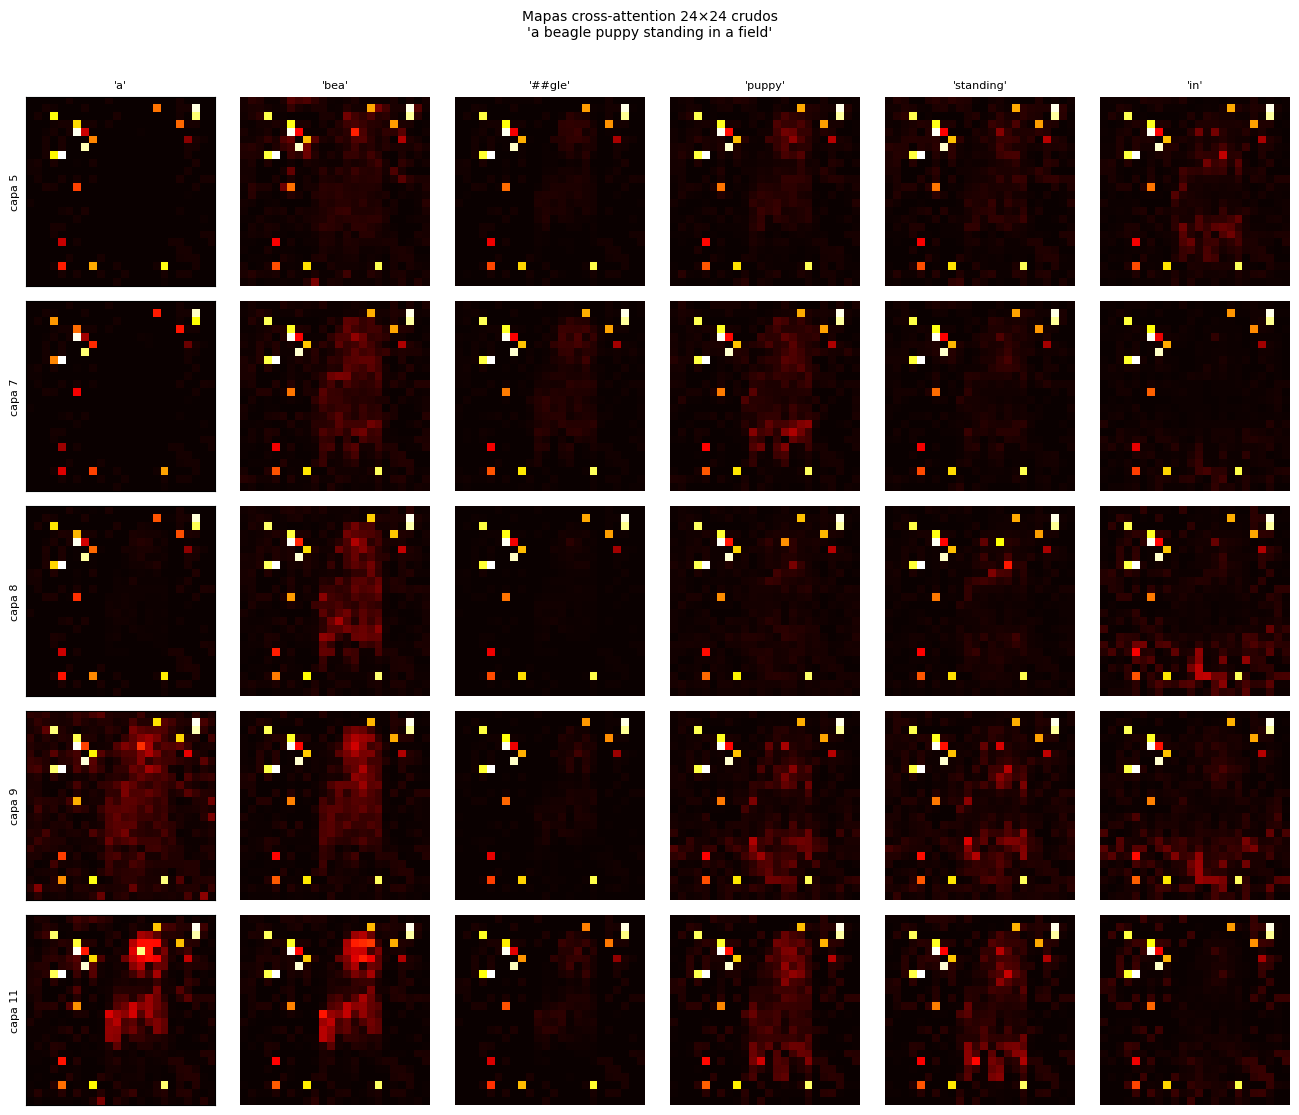

In [10]:
n_words = min(6, len(tokens))
n_layers = len(LAYER_RANGE)

fig, axes = plt.subplots(
    n_layers, n_words,
    figsize=(n_words * 2.2, n_layers * 2.2),
    dpi=100,
)
# asegurar que axes sea siempre 2D
if n_layers == 1:
    axes = axes[np.newaxis, :]
if n_words == 1:
    axes = axes[:, np.newaxis]

for row, layer_idx in enumerate(LAYER_RANGE):
    maps = layer_stats[layer_idx]["maps"]
    for col in range(n_words):
        ax = axes[row, col]
        if col < len(maps):
            m = maps[col]
            m_norm = (m - m.min()) / (m.max() - m.min() + 1e-8)
            ax.imshow(m_norm, cmap="hot", vmin=0, vmax=1)
            if row == 0:
                ax.set_title(f"'{tokens[col]}'", fontsize=8)
        else:
            ax.imshow(np.zeros((24, 24)), cmap="hot", vmin=0, vmax=1)
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(f"capa {layer_idx}", fontsize=8)
            ax.axis("on")
            ax.set_xticks([])
            ax.set_yticks([])

fig.suptitle(
    f"Mapas cross-attention 24×24 crudos\n'{caption}'",
    fontsize=10, y=1.01
)
plt.tight_layout()
plt.show()

## 10. Verificación del pipeline completo — `eval_and_extract_cross_att`

Prueba el módulo con los parámetros actuales y calcula la similitud coseno entre el mapa
de la primera palabra y el de cada una de las restantes.

- **cosine ≈ 1.0** → mapas prácticamente idénticos (el bug sigue presente).
- **cosine < 0.9** → hay diferenciación entre palabras (el pipeline funciona).

In [11]:
result = eval_and_extract_cross_att(
    model, processor, inputs, num_batch=1,
    layer_idx=best_layer,
    head_reduction="max",
)[0]

word_maps = result["maps"]   # [(palabra, array(24,24)), ...]
print(f"Caption del módulo : '{result['caption']}'")
print(f"Palabras extraídas : {[w for w, _ in word_maps]}")
print()

# similitud coseno respecto a la primera palabra
def cosine(a, b):
    a, b = a.flatten(), b.flatten()
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))

ref = word_maps[0][1]
print(f"{'Palabra ref':<14}  {'Palabra':<14}  Cosine   Diagnóstico")
print("-" * 60)
for i, (word, m) in enumerate(word_maps):
    if i == 0:
        print(f"  {word:<14}  {'(referencia)':<14}  1.000000")
        continue
    c = cosine(ref, m)
    flag = "⚠️ idéntico" if c > 0.999 else ("△ muy similar" if c > 0.95 else "✓ distinto")
    print(f"  {word_maps[0][0]:<14}  {word:<14}  {c:.6f}  {flag}")

Caption del módulo : 'a beagle puppy standing in a field'
Palabras extraídas : ['a', 'beagle', 'puppy', 'standing', 'in', 'a', 'field']

Palabra ref     Palabra         Cosine   Diagnóstico
------------------------------------------------------------
  a               (referencia)    1.000000
  a               beagle          0.993039  △ muy similar
  a               puppy           0.997066  △ muy similar
  a               standing        0.994399  △ muy similar
  a               in              0.986615  △ muy similar
  a               a               0.989105  △ muy similar
  a               field           0.988717  △ muy similar


## 11. Resumen del diagnóstico

## 12. Opción 1 — ¿Qué cambia con `subtract_uniform=True`?

Compara los mapas **con** y **sin** substracción de baseline uniforme (1/576).

- Fila superior: atención bruta normalizada a [0,1] — amplifica ruido plano
- Fila inferior: `relu(attn − 1/576)` normalizado — solo las desviaciones positivas

Si las filas inferiores son visualmente distintas entre columnas, el fix funciona.

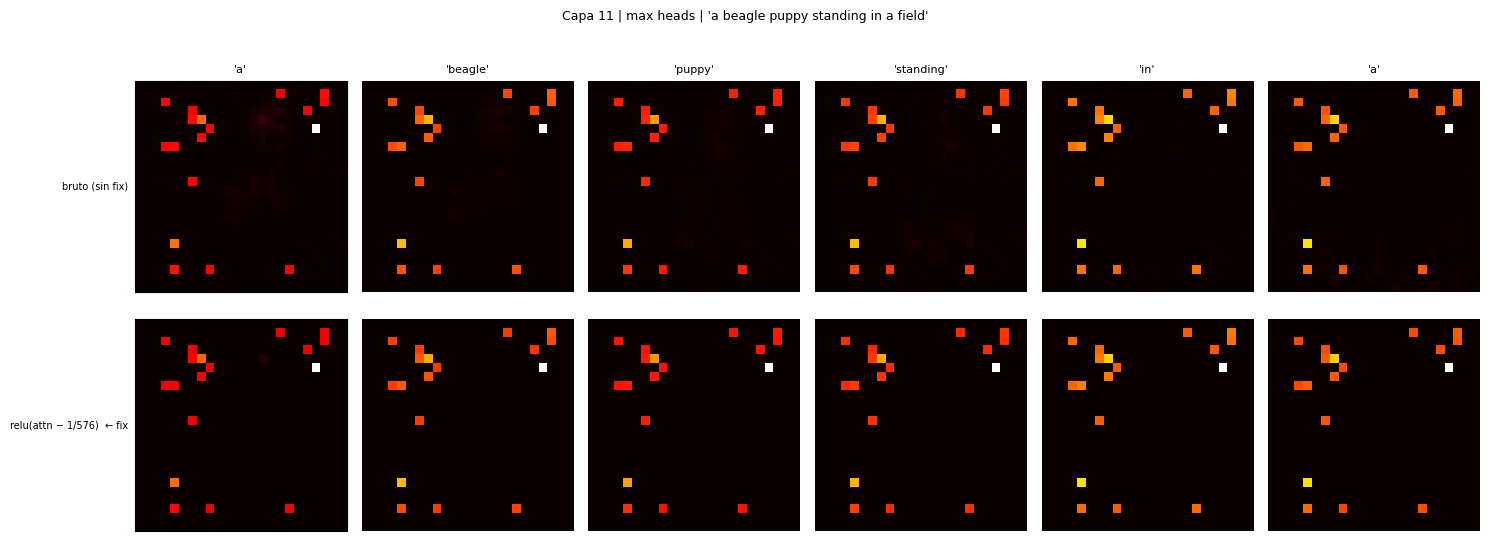

Cosine similaridad CON fix (respecto a la primera palabra):
  'a' (ref)  : 1.000000
  'beagle'          : 0.992825  ⚠️ muy similar
  'puppy'           : 0.998128  ⚠️ muy similar
  'standing'        : 0.995647  ⚠️ muy similar
  'in'              : 0.987190  ⚠️ muy similar
  'a'               : 0.990902  ⚠️ muy similar
  'field'           : 0.989836  ⚠️ muy similar


In [12]:
import importlib
import src.interpretability.cross_attention as ca_mod
importlib.reload(ca_mod)
from src.interpretability.cross_attention import eval_and_extract_cross_att

n_words = min(6, len(tokens))

# ── extraer con y sin substracción ────────────────────────────────────────
result_raw = eval_and_extract_cross_att(
    model, processor, inputs, num_batch=1,
    layer_idx=best_layer, head_reduction="max",
    subtract_uniform=False,
)[0]

result_fix = eval_and_extract_cross_att(
    model, processor, inputs, num_batch=1,
    layer_idx=best_layer, head_reduction="max",
    subtract_uniform=True,
)[0]

# ── figura 2 filas × n_words columnas ────────────────────────────────────
fig, axes = plt.subplots(2, n_words, figsize=(n_words * 2.5, 5.5), dpi=100)

row_labels = ["bruto (sin fix)", f"relu(attn − 1/576)  ← fix"]

for col in range(n_words):
    for row, result in enumerate([result_raw, result_fix]):
        ax = axes[row, col]
        if col < len(result["maps"]):
            word, m = result["maps"][col]
            m_norm = (m - m.min()) / (m.max() - m.min() + 1e-8)
            ax.imshow(m_norm, cmap="hot", vmin=0, vmax=1)
            if row == 0:
                ax.set_title(f"'{word}'", fontsize=8)
        else:
            ax.imshow(np.zeros((24, 24)), cmap="hot")
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(row_labels[row], fontsize=7, rotation=0, labelpad=5, ha="right", va="center")
            ax.axis("on"); ax.set_xticks([]); ax.set_yticks([])

fig.suptitle(
    f"Capa {best_layer} | max heads | '{result_raw['caption']}'",
    fontsize=9, y=1.01,
)
plt.tight_layout()
plt.show()

# ── cosine similaridad con fix ────────────────────────────────────────────
maps_fix = result_fix["maps"]
ref_fix  = maps_fix[0][1]
print("Cosine similaridad CON fix (respecto a la primera palabra):")
for i, (word, m) in enumerate(maps_fix):
    if i == 0:
        print(f"  '{word}' (ref)  : 1.000000")
        continue
    c = float(np.dot(ref_fix.flatten(), m.flatten()) /
              (np.linalg.norm(ref_fix) * np.linalg.norm(m) + 1e-12))
    flag = "⚠️ muy similar" if c > 0.95 else "✓ distinto"
    print(f"  '{word}'{'':>{12 - len(word)}}    : {c:.6f}  {flag}")

## 13. Diagnóstico estructural — ¿Q, K, o heads?

Hasta acá los chequeos de extracción dan ✓ pero los mapas siguen iguales. Falta investigar **antes** de la agregación:

| Test | Mide | Si falla → conclusión |
|------|------|------------------------|
| **A** Heads individuales por token | ¿Hay heads con señal espacial coherente? | Si todas planas → no es problema de `max`/`mean` |
| **B** Cosine entre los 576 patches del ViT | ¿Los features visuales son distinguibles entre sí? | Si cosine > 0.9 → ningún Q puede atender selectivo |
| **C** Norma L2 por patch | ¿Hay anchor patches con norma desproporcionada? | Si max/min > 10 → atención dominada por norma |
| **D** Cosine entre Q's de cada paso decoder | ¿Los Q diferencian los tokens? | Si Q-cosine > 0.95 → decoder no diferencia tokens |

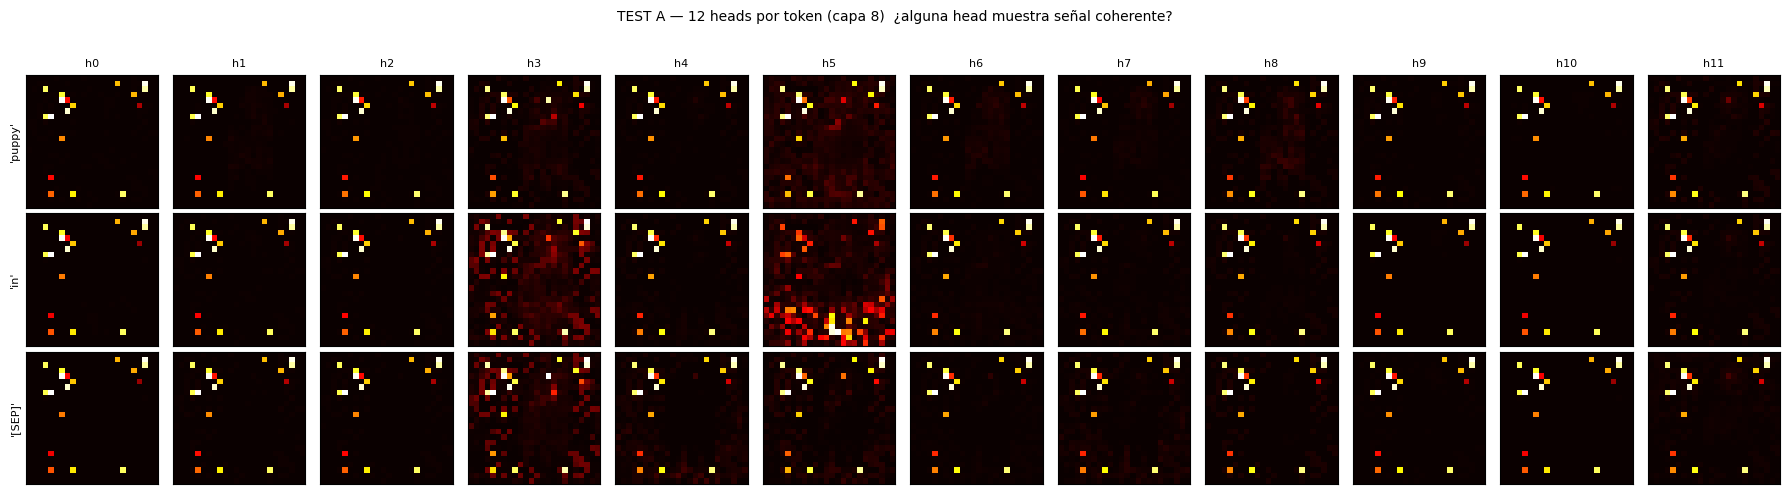

Entropía por head (mean sobre los 3 tokens, log(576)=6.36 = uniforme):
  h 0: entropy=3.229  (peaked si << 6.36)
  h 1: entropy=3.365  (peaked si << 6.36)
  h 2: entropy=3.283  (peaked si << 6.36)
  h 3: entropy=4.979  (peaked si << 6.36)
  h 4: entropy=3.865  (peaked si << 6.36)
  h 5: entropy=5.135  (peaked si << 6.36)
  h 6: entropy=3.849  (peaked si << 6.36)
  h 7: entropy=3.871  (peaked si << 6.36)
  h 8: entropy=3.873  (peaked si << 6.36)
  h 9: entropy=3.298  (peaked si << 6.36)
  h10: entropy=3.146  (peaked si << 6.36)
  h11: entropy=3.960  (peaked si << 6.36)

TEST B — Cosine pairwise entre los 576 patch features:
  mean = 0.294   min = -0.889   max = 1.000
  → ✓ patches distinguibles

TEST C — Norma L2 de los 576 patches:
  mean = 15.244   std = 4.484
  min  = 0.546   max = 17.954   ratio = 32.87x
  → ⚠️ hay anchors (>10x)



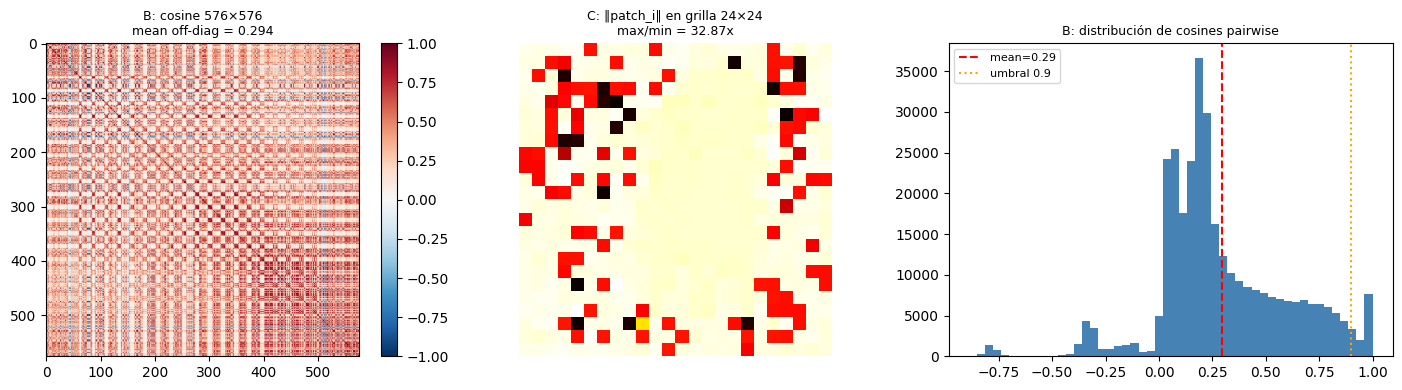

TEST D — Cosine pairwise entre los Q's del decoder (capa 8):
  mean off-diag = 0.631   min = 0.420   max = 0.919
  → ✓ Qs diferenciados


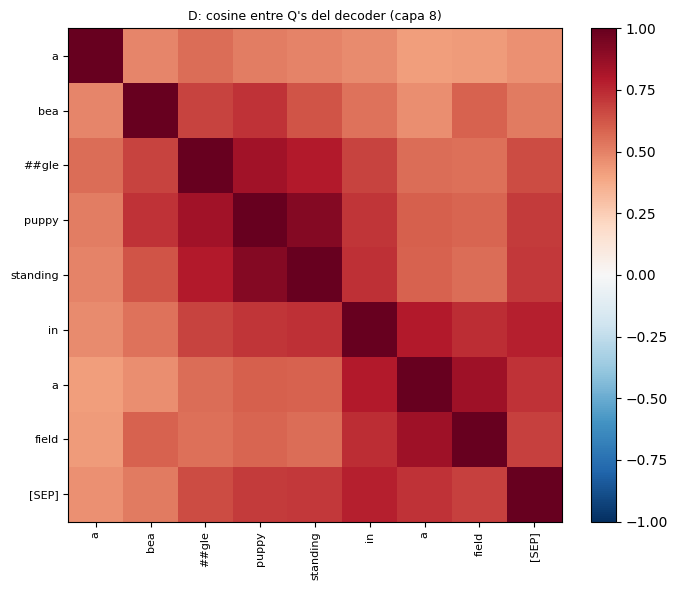

VEREDICTO ESTRUCTURAL
  B  patches del ViT casi-isomorfos   : ✓ no
  C  hay anchor patches por norma     : ⚠️ SÍ — atención dominada por norma
  D  Q's del decoder iguales          : ✓ no

  A  revisar visualmente arriba: ¿hay heads individuales con patrones DISTINTOS
     entre los 3 tokens? Si SÍ → problema es la agregación.
                              Si NO → problema es estructural.


In [13]:
import torch.nn.functional as F

# =========================================================================
# TEST A — heads individuales por token (12 heads × 3 tokens)
# =========================================================================
SELECTED_TOKENS = [3, 5, 8]   # ej: 'people', 'at', 'eating'  (ajustar si hace falta)
SELECTED_TOKENS = [i for i in SELECTED_TOKENS if i < len(tokens)]

n_rows = len(SELECTED_TOKENS)
fig, axes = plt.subplots(n_rows, 12, figsize=(18, n_rows * 1.6), dpi=100)
if n_rows == 1:
    axes = axes[np.newaxis, :]

for row, tok_idx in enumerate(SELECTED_TOKENS):
    attn = captured_raw[tok_idx][0]    # (12, 1, 577)
    for h in range(12):
        m = attn[h, 0, 1:].numpy().reshape(24, 24)
        m_norm = (m - m.min()) / (m.max() - m.min() + 1e-8)
        axes[row, h].imshow(m_norm, cmap="hot", vmin=0, vmax=1)
        axes[row, h].set_xticks([]); axes[row, h].set_yticks([])
        if row == 0:
            axes[row, h].set_title(f"h{h}", fontsize=8)
        if h == 0:
            axes[row, h].set_ylabel(f"'{tokens[tok_idx]}'", fontsize=8)

fig.suptitle(
    f"TEST A — 12 heads por token (capa {LAYER_DIAG})  ¿alguna head muestra señal coherente?",
    fontsize=10, y=1.02,
)
plt.tight_layout()
plt.show()

# entropía por head — más baja = más peaked
print("Entropía por head (mean sobre los 3 tokens, log(576)=6.36 = uniforme):")
for h in range(12):
    es = []
    for tok_idx in SELECTED_TOKENS:
        p = captured_raw[tok_idx][0, h, 0, 1:].numpy()
        p = p / (p.sum() + 1e-12)
        es.append(-(p * np.log(p + 1e-12)).sum())
    print(f"  h{h:2d}: entropy={np.mean(es):.3f}  (peaked si << 6.36)")
print()

# =========================================================================
# TEST B + C — patch features del ViT: cosine pairwise + norma L2
# =========================================================================
with torch.no_grad():
    vis_out = model.vision_model(inputs["pixel_values"])
patch_feats = vis_out.last_hidden_state[0, 1:].cpu()    # (576, D) — sin CLS

norms = patch_feats.norm(dim=-1).numpy()                 # (576,)
feats_norm = F.normalize(patch_feats, dim=-1)
cos_matrix = (feats_norm @ feats_norm.T).numpy()         # (576, 576)
cos_off_diag = cos_matrix[~np.eye(576, dtype=bool)]

print(f"TEST B — Cosine pairwise entre los 576 patch features:")
print(f"  mean = {cos_off_diag.mean():.3f}   "
      f"min = {cos_off_diag.min():.3f}   "
      f"max = {cos_off_diag.max():.3f}")
print(f"  → {'⚠️ patches casi-isomorfos' if cos_off_diag.mean() > 0.9 else '✓ patches distinguibles'}")
print()
print(f"TEST C — Norma L2 de los 576 patches:")
print(f"  mean = {norms.mean():.3f}   std = {norms.std():.3f}")
print(f"  min  = {norms.min():.3f}   max = {norms.max():.3f}   ratio = {norms.max()/norms.min():.2f}x")
print(f"  → {'⚠️ hay anchors (>10x)' if norms.max()/norms.min() > 10 else '✓ normas comparables'}")
print()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=100)
im0 = axes[0].imshow(cos_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
axes[0].set_title(f"B: cosine 576×576\nmean off-diag = {cos_off_diag.mean():.3f}", fontsize=9)
plt.colorbar(im0, ax=axes[0], fraction=0.046)

axes[1].imshow(norms.reshape(24, 24), cmap="hot")
axes[1].set_title(f"C: ‖patch_i‖ en grilla 24×24\nmax/min = {norms.max()/norms.min():.2f}x", fontsize=9)
axes[1].axis("off")

axes[2].hist(cos_off_diag, bins=50, color="steelblue")
axes[2].axvline(cos_off_diag.mean(), color="r", linestyle="--", label=f"mean={cos_off_diag.mean():.2f}")
axes[2].axvline(0.9, color="orange", linestyle=":", label="umbral 0.9")
axes[2].set_title("B: distribución de cosines pairwise", fontsize=9)
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()

# =========================================================================
# TEST D — Q vectors de cada paso decoder
# =========================================================================
captured_q = []

def hook_q(m, inp, out):
    # out shape esperado: (1, 1, 768) — Q por paso con KV-cache
    if out.dim() == 3 and out.shape[-1] == 768:
        captured_q.append(out.detach().clone())

q_module = model.text_decoder.bert.encoder.layer[LAYER_DIAG].crossattention.self.query
q_handle = q_module.register_forward_hook(hook_q)

with torch.no_grad():
    _ = model.generate(
        **inputs, output_attentions=True, return_dict_in_generate=True,
        max_new_tokens=40, num_beams=1,
    )
q_handle.remove()

# tomar primer Q por paso (concatenando) — quedarse con n_tokens pasos
q_per_step = torch.cat([q[0] for q in captured_q[:len(tokens)]], dim=0)  # (n_tokens, 768)
q_norm     = F.normalize(q_per_step, dim=-1)
q_cos      = (q_norm @ q_norm.T).numpy()
q_off_diag = q_cos[~np.eye(len(tokens), dtype=bool)]

print(f"TEST D — Cosine pairwise entre los Q's del decoder (capa {LAYER_DIAG}):")
print(f"  mean off-diag = {q_off_diag.mean():.3f}   "
      f"min = {q_off_diag.min():.3f}   "
      f"max = {q_off_diag.max():.3f}")
print(f"  → {'⚠️ Qs no diferencian tokens' if q_off_diag.mean() > 0.95 else '✓ Qs diferenciados'}")

fig, ax = plt.subplots(1, 1, figsize=(7, 6), dpi=100)
im = ax.imshow(q_cos, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(tokens))); ax.set_yticks(range(len(tokens)))
ax.set_xticklabels(tokens, rotation=90, fontsize=8)
ax.set_yticklabels(tokens, fontsize=8)
ax.set_title(f"D: cosine entre Q's del decoder (capa {LAYER_DIAG})", fontsize=9)
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

# =========================================================================
# VEREDICTO
# =========================================================================
print("=" * 60)
print("VEREDICTO ESTRUCTURAL")
print("=" * 60)
A_fail = False  # se evalúa visualmente
B_fail = cos_off_diag.mean() > 0.9
C_fail = norms.max() / norms.min() > 10
D_fail = q_off_diag.mean() > 0.95

print(f"  B  patches del ViT casi-isomorfos   : {'⚠️ SÍ — bloqueo arquitectónico' if B_fail else '✓ no'}")
print(f"  C  hay anchor patches por norma     : {'⚠️ SÍ — atención dominada por norma' if C_fail else '✓ no'}")
print(f"  D  Q's del decoder iguales          : {'⚠️ SÍ — decoder no diferencia tokens' if D_fail else '✓ no'}")
print()
print("  A  revisar visualmente arriba: ¿hay heads individuales con patrones DISTINTOS")
print("     entre los 3 tokens? Si SÍ → problema es la agregación.")
print("                              Si NO → problema es estructural.")

In [14]:
# ── recolectar veredictos ──────────────────────────────────────────────────
beam_ok   = model.generation_config.num_beams == 1
align_ok  = abs(len(captured_raw) - len(tokens)) <= 1
T_vals    = [captured_raw[i].shape[2] for i in range(min(len(captured_raw), len(tokens)))]
T_ok      = all(t == 1 for t in T_vals) or T_vals == list(range(1, len(T_vals)+1))
diffs     = [
    (vecs[i] - vecs[i-1]).abs().max().item()
    for i in range(1, min(len(vecs), len(tokens)))
]
clone_ok  = all(d > 1e-6 for d in diffs) if diffs else False

cosines   = [cosine(ref, m) for _, m in word_maps[1:]]
signal_ok = all(c < 0.999 for c in cosines) if cosines else False

print("=" * 60)
print("RESUMEN — diagnóstico cross-attention")
print("=" * 60)
print(f"  Beam search desactivado     : {'✓' if beam_ok   else '⚠️  FIX: agregar num_beams=1 a generate()'}")
print(f"  Alineación hook ↔ tokens    : {'✓' if align_ok  else '⚠️  hook dispara más veces de lo esperado'}")
print(f"  Dimensión T correcta        : {'✓' if T_ok      else '⚠️  revisar indexación en eje temporal'}")
print(f"  Capturas son distintas      : {'✓' if clone_ok  else '⚠️  clone() no diferencia las capturas'}")
print(f"  Mapas diferenciados (cosine): {'✓' if signal_ok else '⚠️  mapas con cosine > 0.999 — señal degenerada'}")
print()
print(f"  Capa con mayor variabilidad : {best_layer}")
print(f"  Between-word std por capa   :")
for layer_idx in LAYER_RANGE:
    s = layer_stats[layer_idx]['between_word_std']
    marker = "  ←" if layer_idx == best_layer else ""
    print(f"    capa {layer_idx:2d}: {s:.5f}{marker}")

RESUMEN — diagnóstico cross-attention
  Beam search desactivado     : ✓
  Alineación hook ↔ tokens    : ✓
  Dimensión T correcta        : ✓
  Capturas son distintas      : ✓
  Mapas diferenciados (cosine): ✓

  Capa con mayor variabilidad : 11
  Between-word std por capa   :
    capa  5: 0.00097
    capa  7: 0.00126
    capa  8: 0.00138
    capa  9: 0.00165
    capa 11: 0.00167  ←


## 14. Visualización final — heatmaps con `norm_correct=True`

Muestra dónde miró el modelo al predecir cada palabra seleccionada.  
Cada subplot superpone el mapa de atención sobre la imagen original.

Ajustá `WORD_INDICES` si querés ver otras palabras.

Caption : 'a beagle puppy standing in a field'
Palabras: ['a', 'beagle', 'puppy', 'standing', 'in', 'a', 'field']



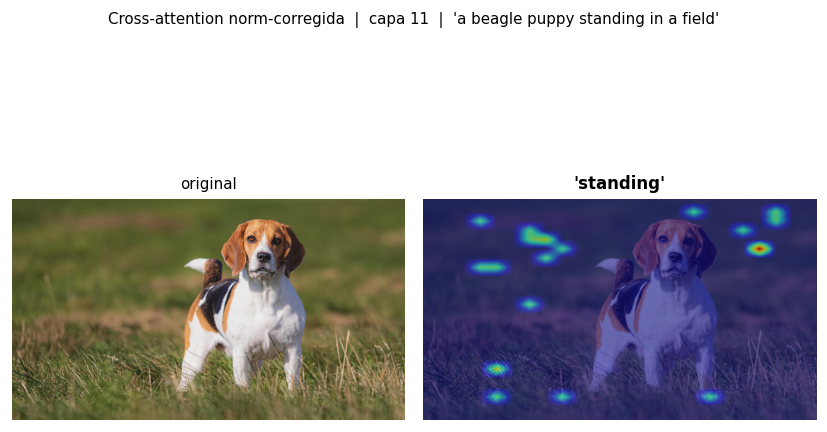

In [15]:
import importlib
import src.interpretability.cross_attention as ca_mod
import src.visualization.heatmap as hm_mod
importlib.reload(ca_mod)
importlib.reload(hm_mod)
from src.interpretability.cross_attention import eval_and_extract_cross_att
from src.visualization.heatmap import overlay_heatmap

# ── palabras a visualizar (índices en result["maps"]) ─────────────────────
WORD_INDICES = [3, 7, 8]   # ej: 'people', 'table', 'eating' — ajustar si cambia el caption

result = eval_and_extract_cross_att(
    model, processor, inputs, num_batch=1,
    layer_idx=best_layer,
    head_reduction="max",
    norm_correct=True,
    subtract_uniform=False,
)[0]

words_all = result["maps"]
print(f"Caption : '{result['caption']}'")
print(f"Palabras: {[w for w, _ in words_all]}")
print()

# filtrar índices válidos
WORD_INDICES = [i for i in WORD_INDICES if i < len(words_all)]
selected = [words_all[i] for i in WORD_INDICES]

# ── figura: original + un subplot por palabra ─────────────────────────────
n_cols = 1 + len(selected)
fig, axes = plt.subplots(1, n_cols, figsize=(n_cols * 3.5, 4.5), dpi=120)

axes[0].imshow(image)
axes[0].set_title("original", fontsize=9)
axes[0].axis("off")

for col, (word, heatmap) in enumerate(selected, start=1):
    overlay = overlay_heatmap(image, heatmap, alpha=0.55, colormap="jet")
    axes[col].imshow(overlay)
    axes[col].set_title(f"'{word}'", fontsize=10, fontweight="bold")
    axes[col].axis("off")

fig.suptitle(
    f"Cross-attention norm-corregida  |  capa {best_layer}  |  '{result['caption']}'",
    fontsize=9, y=1.02,
)
plt.tight_layout()
plt.show()

# ── diferencia visual entre mapas (confirma distinción) ──────────────────
if len(selected) >= 2:
    print("Max diff entre heatmaps seleccionados:")
    for i in range(len(selected)):
        for j in range(i + 1, len(selected)):
            d = np.abs(selected[i][1] - selected[j][1]).max()
            print(f"  '{selected[i][0]}' vs '{selected[j][0]}': {d:.5f}")

## 15. Última opción — `logit_space=True` (scores pre-softmax)

`log(softmax(s_i)) = s_i − log(Z)` recupera los logits pre-softmax salvo una constante por paso.  
El softmax aplana diferencias: si patch A tiene logit 2× mayor que patch B, post-softmax la diferencia es mínima sobre 576 opciones. En espacio log, esa diferencia se preserva linealmente.

Se prueba con y sin `norm_correct` para ver si la combinación ayuda.

Caption: 'a beagle puppy standing in a field'
Palabras disponibles: ['a', 'beagle', 'puppy', 'standing', 'in', 'a', 'field']



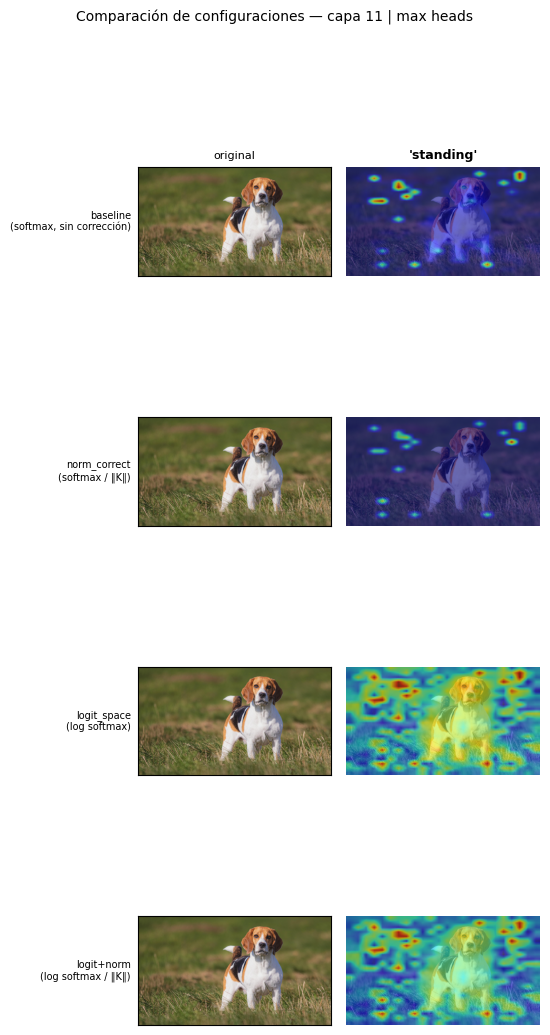

Cosine entre 'people' y las otras palabras (más bajo = más distinto):
Configuración                        
-----------------------------------------------------------------
  baseline (softmax, sin corrección)
  norm_correct (softmax / ‖K‖)     
  logit_space (log softmax)        
  logit+norm (log softmax / ‖K‖)   


In [16]:
import importlib
import src.interpretability.cross_attention as ca_mod
importlib.reload(ca_mod)
from src.interpretability.cross_attention import eval_and_extract_cross_att
from src.visualization.heatmap import overlay_heatmap

WORD_INDICES = [3, 7, 8]   # 'people', 'table', 'eating'

configs = [
    dict(logit_space=False, norm_correct=False, label="baseline\n(softmax, sin corrección)"),
    dict(logit_space=False, norm_correct=True,  label="norm_correct\n(softmax / ‖K‖)"),
    dict(logit_space=True,  norm_correct=False, label="logit_space\n(log softmax)"),
    dict(logit_space=True,  norm_correct=True,  label="logit+norm\n(log softmax / ‖K‖)"),
]

words_labels = None
all_results  = []
for cfg in configs:
    r = eval_and_extract_cross_att(
        model, processor, inputs, num_batch=1,
        layer_idx=best_layer, head_reduction="max",
        logit_space=cfg["logit_space"],
        norm_correct=cfg["norm_correct"],
        subtract_uniform=False,
    )[0]
    all_results.append(r)
    if words_labels is None:
        words_labels = [w for w, _ in r["maps"]]

print(f"Caption: '{all_results[0]['caption']}'")
print(f"Palabras disponibles: {words_labels}")
print()

valid_idx = [i for i in WORD_INDICES if i < len(words_labels)]
n_words   = len(valid_idx)
n_configs = len(configs)

# ── figura: filas = configuraciones, columnas = palabras ─────────────────
fig, axes = plt.subplots(
    n_configs, n_words + 1,
    figsize=((n_words + 1) * 2.8, n_configs * 2.8),
    dpi=100,
)

for row, (cfg, result) in enumerate(zip(configs, all_results)):
    # imagen original en primera columna
    axes[row, 0].imshow(image)
    axes[row, 0].axis("off")
    axes[row, 0].set_ylabel(cfg["label"], fontsize=7, rotation=0,
                             labelpad=5, ha="right", va="center")
    axes[row, 0].axis("on"); axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])
    if row == 0:
        axes[row, 0].set_title("original", fontsize=8)

    for col, word_idx in enumerate(valid_idx, start=1):
        word, heatmap = result["maps"][word_idx]
        overlay = overlay_heatmap(image, heatmap, alpha=0.55, colormap="jet")
        axes[row, col].imshow(overlay)
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(f"'{word}'", fontsize=9, fontweight="bold")

fig.suptitle(
    f"Comparación de configuraciones — capa {best_layer} | max heads",
    fontsize=10, y=1.01,
)
plt.tight_layout()
plt.show()

# ── cosine similarity para cada configuración ─────────────────────────────
print("Cosine entre 'people' y las otras palabras (más bajo = más distinto):")
print(f"{'Configuración':<35}  ", end="")
if len(valid_idx) >= 2:
    for j in valid_idx[1:]:
        print(f"  vs '{words_labels[j]}'", end="")
print()
print("-" * 65)
for cfg, result in zip(configs, all_results):
    ref = result["maps"][valid_idx[0]][1].flatten()
    print(f"  {cfg['label'].replace(chr(10), ' '):<33}", end="")
    for j in valid_idx[1:]:
        m = result["maps"][j][1].flatten()
        denom = np.linalg.norm(ref) * np.linalg.norm(m) + 1e-12
        c = float(np.dot(ref, m) / denom)
        print(f"    {c:.4f}", end="")
    print()

## 16. Q·K directo — scores pre-softmax sin pasar por softmax

En lugar de `log(softmax(s))`, calculamos `Q·K^T / √d` directamente capturando
los vectores **Q y K ya proyectados** vía hooks sobre `crossattention.self.query`
y `crossattention.self.key`.

Esto evita **completamente** el aplastamiento del softmax. El mapa resultante es
la similitud directa (en espacio proyectado) entre el query del token y cada patch visual.

Si **estos** mapas también son iguales entre palabras → conclusión definitiva:
el decoder de BLIP no discrimina espacialmente por palabra en su cross-attention.

Caption : 'a beagle puppy standing in a field'
Palabras: ['a', 'beagle', 'puppy', 'standing', 'in', 'a', 'field']



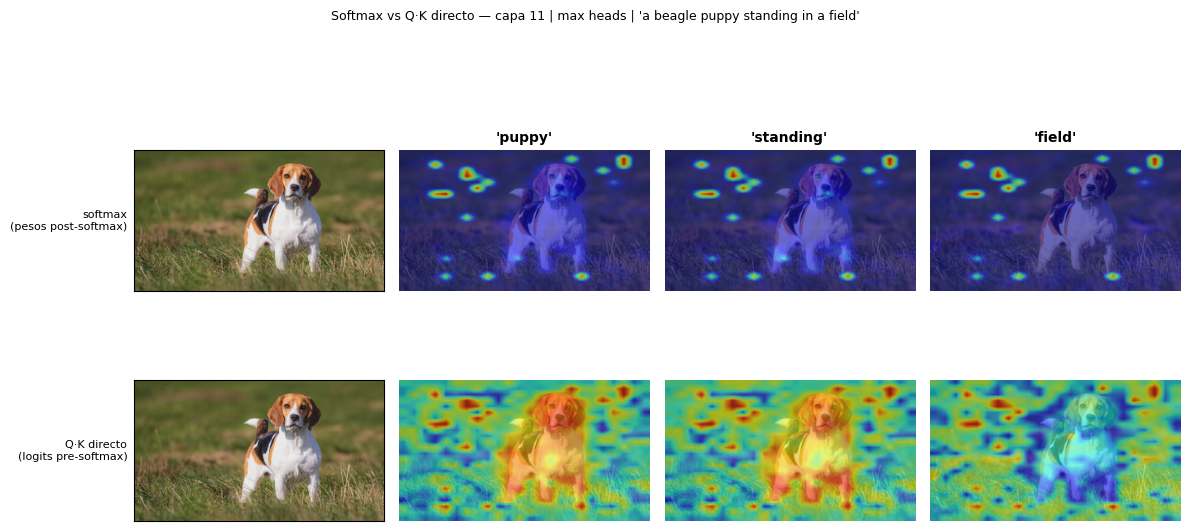

                                       vs 'standing'  vs 'field'
------------------------------------------------------------
  softmax (pesos post-softmax)         0.9938 ⚠️    0.9459 ✓
  Q·K directo (logits pre-softmax)     0.9972 ⚠️    0.8544 ✓


In [17]:
import importlib
import src.interpretability.cross_attention as ca_mod
importlib.reload(ca_mod)
from src.interpretability.cross_attention import eval_and_extract_qk_logits
from src.visualization.heatmap import overlay_heatmap

WORD_INDICES = [2, 3, 6]   # 'people', 'table', 'eating' / 'puppy', 'standing', 'field'

result_qk = eval_and_extract_qk_logits(
    model, processor, inputs, num_batch=1,
    layer_idx=best_layer,
    head_reduction="max",
)[0]

result_base = eval_and_extract_cross_att(
    model, processor, inputs, num_batch=1,
    layer_idx=best_layer, head_reduction="max",
    norm_correct=False, logit_space=False,
)[0]

words_qk = result_qk["maps"]
print(f"Caption : '{result_qk['caption']}'")
print(f"Palabras: {[w for w, _ in words_qk]}")
print()

valid_idx = [i for i in WORD_INDICES if i < len(words_qk)]
n_words   = len(valid_idx)

# ── figura: 2 filas × (1 original + n_words palabras) ────────────────────
fig, axes = plt.subplots(2, n_words + 1, figsize=((n_words + 1) * 3, 6), dpi=100)

row_labels = ["softmax\n(pesos post-softmax)", "Q·K directo\n(logits pre-softmax)"]
results    = [result_base, result_qk]

for row in range(2):
    # columna 0: imagen original
    axes[row, 0].imshow(image)
    axes[row, 0].axis("off")
    axes[row, 0].set_ylabel(row_labels[row], fontsize=8, rotation=0,
                             labelpad=5, ha="right", va="center")
    axes[row, 0].axis("on"); axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])

    for col_i, word_idx in enumerate(valid_idx):
        col  = col_i + 1
        word, hm = results[row]["maps"][word_idx]
        overlay  = overlay_heatmap(image, hm, alpha=0.55, colormap="jet")
        axes[row, col].imshow(overlay)
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(f"'{word}'", fontsize=10, fontweight="bold")

fig.suptitle(
    f"Softmax vs Q·K directo — capa {best_layer} | max heads | '{result_qk['caption']}'",
    fontsize=9, y=1.02,
)
plt.tight_layout()
plt.show()

# ── cosine similarity para ambos métodos ─────────────────────────────────
print(f"{'':35}  ", end="")
for j in valid_idx[1:]:
    print(f"  vs '{words_qk[j][0]}'", end="")
print()
print("-" * 60)

for label, result in zip(row_labels, results):
    ref = result["maps"][valid_idx[0]][1].flatten()
    label_clean = label.replace("\n", " ")
    print(f"  {label_clean:<33}", end="")
    for j in valid_idx[1:]:
        m     = result["maps"][j][1].flatten()
        c     = float(np.dot(ref, m) / (np.linalg.norm(ref) * np.linalg.norm(m) + 1e-12))
        flag  = "⚠️" if c > 0.99 else ("△" if c > 0.95 else "✓")
        print(f"    {c:.4f} {flag}", end="")
    print()